In [1]:
import sys
sys.path.insert(0, "../")

import numpy as np
import matplotlib.pyplot as plt
from src.config import MOTOR_CHANNELS, CLASS_NAMES

In [2]:
print(f"Labels: {CLASS_NAMES}")
print(f"Channels: {MOTOR_CHANNELS}")

Labels: ('elbow_flex_ext', 'hand_open_close', 'forearm_sup_pron', 'rest')
Channels: ['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6']


In [3]:
train_dataset = "../data/processed/dataset_train.npz"
test_dataset = "../data/processed/dataset_test.npz"

## **Load Data**

In [4]:
def load_npz_split(path) -> tuple[np.ndarray, np.ndarray, dict]:
    z = np.load(path, allow_pickle=True)
    X = np.asarray(z["X"], dtype=np.float64)
    X_psd = np.asarray(z["X_psd"], dtype=np.float64)
    y = np.asarray(z["y"]).astype(np.int64).ravel()
    meta = {
        "sfreq": float(np.asarray(z["sfreq"]).squeeze()),
        "ch_names": [str(x) for x in np.asarray(z["ch_names"], dtype=object).ravel()],
        "split": str(np.asarray(z["split"]).ravel()[0]),
        "path": path,
    }
    return X, X_psd, y, meta

X_train, X_psd_train, y_train, train_meta = load_npz_split(train_dataset)
X_test, X_psd_test, y_test, test_meta = load_npz_split(test_dataset)

## *Visualize the data*

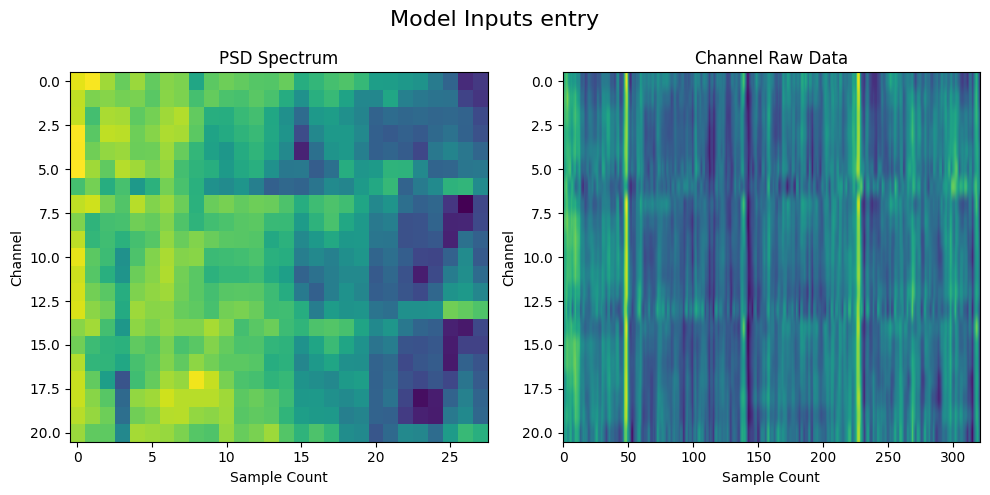

In [5]:
idx = 0
psd_sample = X_psd_train[idx]
raw_sample = X_train[idx]
fig, axes = plt.subplots(1,2, figsize=(10, 5))

axes[0].imshow(psd_sample, aspect="auto")
axes[0].set_xlabel("Sample Count")
axes[0].set_ylabel("Channel")
axes[0].set_title("PSD Spectrum")

axes[1].imshow(raw_sample, aspect="auto")
axes[1].set_xlabel("Sample Count")
axes[1].set_ylabel("Channel")
axes[1].set_title("Channel Raw Data")


plt.suptitle("Model Inputs entry", fontsize=16)
plt.tight_layout()
plt.show()

The image shows that the signal contains 21 concatenated chunks Channels) of 28 samples (3-30Hz) from the calculated welch PSD.

This will give us information of the spectral changes among channels through time for the different epochs.

## **Train the model**

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from src.networks import EEGPsdNet

### **Build the training dataset**

In [7]:
class EEGPsdDataset(Dataset):
    def __init__(self, X_raw, X_psd, y, is_train=False, crop_size=256):
        self.X_raw = torch.from_numpy(X_raw).float()
        self.X_psd = torch.from_numpy(X_psd).float()
        self.y = torch.from_numpy(y).long()
        self.is_train = is_train
        self.crop_size = crop_size
        
        if self.X_raw.ndim == 3:
            self.X_raw = self.X_raw.unsqueeze(1)
        if self.X_psd.ndim == 3:
            self.X_psd = self.X_psd.unsqueeze(1)
            
        self.max_time = self.X_raw.shape[-1] # Should be 321

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        raw = self.X_raw[idx]
        
        # --- TEMPORAL CROPPING ---
        if self.is_train:
            # Pick a random start point
            max_start = self.max_time - self.crop_size
            start = torch.randint(0, max_start + 1, (1,)).item()
        else:
            # Always take the exact center for validation to keep it deterministic
            start = (self.max_time - self.crop_size) // 2
            
        raw_cropped = raw[:, :, start : start + self.crop_size]
        
        return raw_cropped, self.X_psd[idx], self.y[idx]

# Create Datasets and DataLoaders
batch_size = 32

train_ds = EEGPsdDataset(X_train, X_psd_train, y_train)
test_ds = EEGPsdDataset(X_test, X_psd_test, y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [10]:
from torchinfo import summary

# Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# Initialize Model
# Using your 21 channels and 128 sfreq
model = EEGPsdNet(n_channels=21, n_classes=4, sfreq=128).to(device)
summary(model)

Training on: cpu


Layer (type:depth-idx)                   Param #
EEGPsdNet                                --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       512
│    └─BatchNorm2d: 2-2                  16
├─Sequential: 1-2                        --
│    └─Conv2d: 2-3                       672
│    └─BatchNorm2d: 2-4                  64
│    └─ELU: 2-5                          --
│    └─AvgPool2d: 2-6                    --
│    └─Dropout: 2-7                      --
├─Sequential: 1-3                        --
│    └─Conv2d: 2-8                       512
│    └─Conv2d: 2-9                       512
│    └─BatchNorm2d: 2-10                 32
│    └─ELU: 2-11                         --
│    └─AvgPool2d: 2-12                   --
│    └─Dropout: 2-13                     --
├─Sequential: 1-4                        --
│    └─Conv2d: 2-14                      40
│    └─BatchNorm2d: 2-15                 16
│    └─ELU: 2-16                         --
│    └─Conv2d: 2-17    

In [11]:
# Dynamically calculate class weights based on y_train distribution
_, counts = np.unique(y_train, return_counts=True)
class_weights = 1.0 / torch.tensor(counts, dtype=torch.float)
class_weights = class_weights / class_weights.sum()  # Normalize
class_weights = class_weights.to(device)

# Loss and Optimizer (using label smoothing to prevent overconfidence)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
num_epochs = 40

print(f"{'Epoch':<8} | {'Train Loss':<12} | {'Train Acc':<12} | {'Val Loss':<10} | {'Val Acc':<10}")
print("-" * 65)

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for batch_raw, batch_psd, labels in train_loader:
        batch_raw, batch_psd, labels = batch_raw.to(device), batch_psd.to(device), labels.to(device)

        if model.training:
            # Keep the raw cropping and noise
            raw_noise = torch.randn_like(batch_raw) * 0.1
            batch_raw = batch_raw + raw_noise
            
            # Keep a TINY amount of PSD noise, but remove the random erasing mask
            psd_noise = torch.randn_like(batch_psd) * 0.01
            batch_psd = batch_psd + psd_noise
        
        optimizer.zero_grad()
        outputs = model(batch_raw, batch_psd)  # Pass both inputs to the model
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item() * labels.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        
    epoch_train_loss = train_loss / train_total
    epoch_train_acc = 100. * train_correct / train_total

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for batch_raw, batch_psd, labels in test_loader:
            batch_raw, batch_psd, labels = batch_raw.to(device), batch_psd.to(device), labels.to(device)
            
            outputs = model(batch_raw, batch_psd)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * labels.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = 100. * val_correct / val_total
    
    # Store history
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    scheduler.step(epoch_val_loss)
    
    # Print every epoch to monitor the gap between Train and Val
    print(f"{epoch+1:<8} | {epoch_train_loss:<12.4f} | {epoch_train_acc:<10.2f}% | {epoch_val_loss:<10.4f} | {epoch_val_acc:<10.2f}%")

Epoch    | Train Loss   | Train Acc    | Val Loss   | Val Acc   
-----------------------------------------------------------------
1        | 1.2667       | 40.38     % | 1.1261     | 46.56     %
2        | 1.1505       | 48.76     % | 1.0907     | 52.26     %
3        | 1.1374       | 50.99     % | 1.0981     | 52.97     %
4        | 1.1049       | 52.87     % | 1.0605     | 54.16     %
5        | 1.0889       | 54.88     % | 1.0545     | 54.87     %
6        | 1.0734       | 55.18     % | 1.0499     | 55.11     %
7        | 1.0529       | 57.65     % | 1.0600     | 54.16     %
8        | 1.0652       | 55.56     % | 1.0494     | 54.39     %
9        | 1.0448       | 57.32     % | 1.0315     | 60.10     %
10       | 1.0294       | 57.40     % | 1.0258     | 56.53     %
11       | 1.0266       | 59.20     % | 1.0239     | 55.11     %
12       | 1.0140       | 60.50     % | 1.0183     | 57.24     %
13       | 1.0137       | 60.08     % | 1.0079     | 56.06     %
14       | 1.0097       

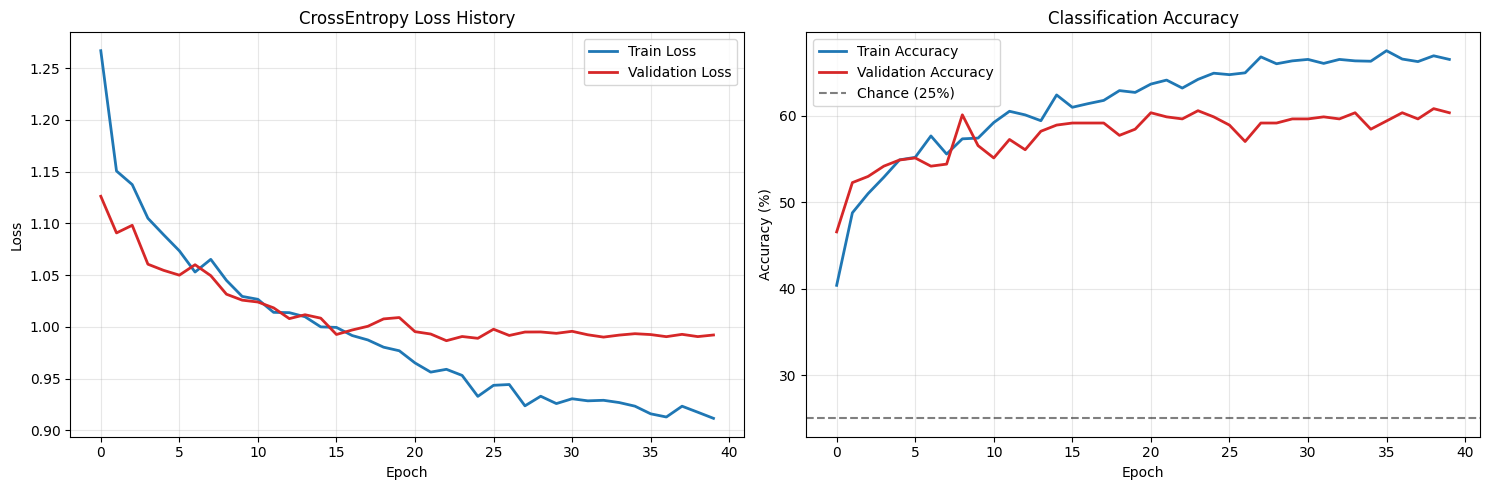

In [12]:
from src.utils import plot_history

plot_history(history)

Extracting bottleneck features from test set...
Running t-SNE (this may take a minute)...


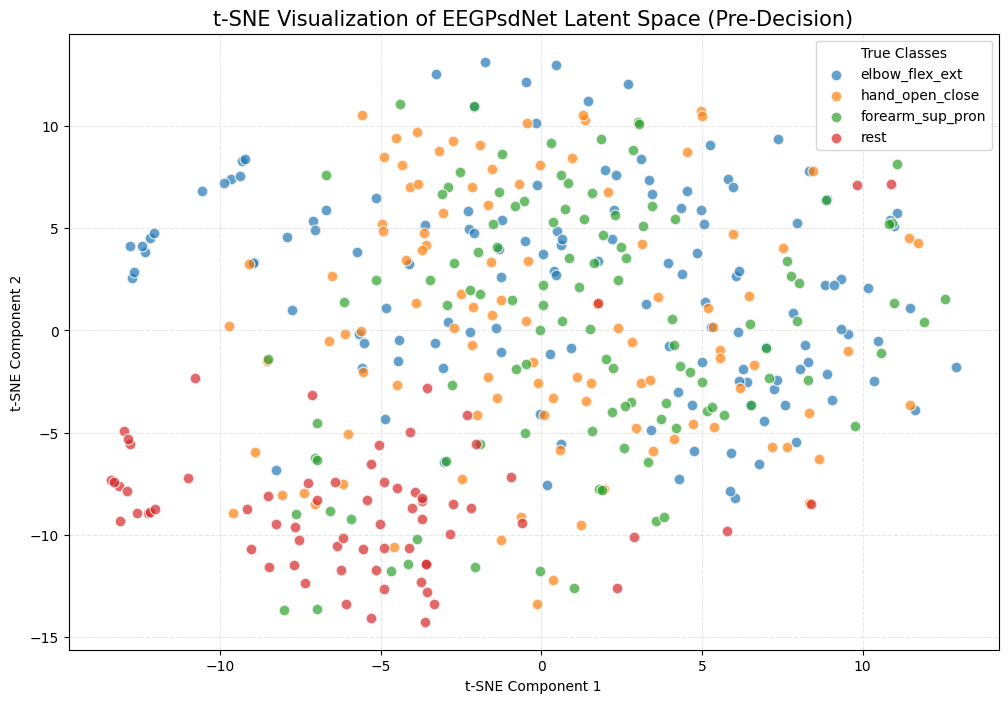

In [15]:
from sklearn.manifold import TSNE

def get_bottleneck_features(model, loader, device):
    model.eval()
    features = []
    labels_list = []
    
    with torch.no_grad():
        for raw_inputs, psd_inputs, labels in loader:
            raw_inputs = raw_inputs.to(device)
            psd_inputs = psd_inputs.to(device)
            
            x1 = model.temporal_conv(raw_inputs)
            x1 = model.spatial_conv(x1)
            x1 = model.separator_conv(x1)
            x1 = torch.flatten(x1, 1)
            
            # Branch 2
            x2 = model.psd_encoder(psd_inputs)
            
            # Concatenate
            combined = torch.cat((x1, x2), dim=1)
            # Normalize the combined features so one branch doesn't dominate
            combined = model.fusion_norm(combined)
            
            features.append(combined.cpu().numpy())
            labels_list.append(labels.numpy())
            
    return np.concatenate(features), np.concatenate(labels_list)

def plot_feature_clusters(model, test_loader, device, class_names):
    # Extract features
    print("Extracting bottleneck features from test set...")
    features, labels = get_bottleneck_features(model, test_loader, device)
    
    # Apply t-SNE
    print("Running t-SNE (this may take a minute)...")
    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
    features_2d = tsne.fit_transform(features)
    
    plt.figure(figsize=(12, 8))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Distinct professional colors
    
    for i, class_name in enumerate(class_names):
        indices = np.where(labels == i)
        plt.scatter(
            features_2d[indices, 0], 
            features_2d[indices, 1], 
            c=colors[i], 
            label=class_name,
            alpha=0.7, 
            edgecolors='w', 
            s=60
        )
    
    plt.title("t-SNE Visualization of EEGPsdNet Latent Space (Pre-Decision)", fontsize=15)
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.legend(title="True Classes", loc='best')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()


plot_feature_clusters(model, test_loader, device, CLASS_NAMES)